# Hybrid Pendulum System

## Monolithic Modelica Reference Solution

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

from OMPython import ModelicaSystem

In [3]:
root = Path.cwd().parent
pkg_path = root / "Modelica/ControlledPendulum/package.mo"
model_name = "ControlledPendulum.Demo_DrivenWithWallDiscrete"

model = ModelicaSystem(str(pkg_path), model_name)

solution_names = ("time", "pid.I_out", "reference.q_ref", "pendulum.q", "pendulum.contact")

startTime = 0.0
stopTime = 10.0
stepSize = 0.0001

model.setParameters("useReset=true")
model.buildModel()
model.setSimulationOptions(
    [f"startTime={startTime}", f"stopTime={stopTime}", f"stepSize={stepSize}"]
)
model.simulate()
res = {name: model.getSolutions(name).flatten() for name in solution_names}


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


# syssimx Co-Simulation

- Implementes controlled pendulum system with wall contact.
- Wall contact is detected via an event indicator in the pendulum FMU.
- The wall is considered at an angle $q=0$. When the pendulum angle crosses this threshold, an event is triggered.
- This event is added to the CoSimComponent via the methof `add_event_indicator`.
- This method takes an event name, a callable that takes the CoSimComponent instance and returns the event indicator value, and a direction parameter to specify the zero-crossing direction to detect. The method creates an event output port for the register.
- To indicate that a CoSimComponent reacts and handles an event, the CoSimComponents needs to subscribe to the event via the method `subscribe_to_event`.
- The actual event handling logic is implemented in the method `_handle_events_internal`, which is called by the CoSimComponent base class when an event is detected.
- This event causes the pendulum FMU to switch its dynamics to account for the wall contact, simulating a bounce effect.
- The wall hit event also resets the integrator in the PID controller FMU to prevent wind-up during the impact. This allows the pendulum to get faster back to the reference track after the wall hit. The error which is integrated by the PID controller is set to zero at the event time.
- The pendulum is setup with an explicit Euler solver. This allows to use the FMI methods `getFMUstate` and `setFMUstate` to store and restore the FMU state for zero-crossing detection.
- Within the system, one has to define event connections between the event output port of the pendulum and the event input port of the PID controller.
- The name of the output port correspond to the event name defined when adding the event indicator.
- By defining an event connection the system knows which components need to be called for the event handling when an event is detected during simulation.
- The system stores the information in a dictionary `_event_targets_by_source` which maps event source ports to a list of target components that need to handle the event.
- The method `dispatch_event` is called by the system when an event is detected during simulation. It looks up the target components for the event source and calls their event handling methods.
- During the initialization of the system, the involved components are classified as event sources, event listeners, or continuous components, based on whether they have event output ports or have subscribed to events.
- If the system contains at least one event source, the system is classified as a hybrid system, and the hybrid simulation algorithm is used during simulation.


### Overview
The hybrid Jacobi co-simulation algorithm extends the standard Jacobi co-simulation algorithm to handle hybrid dynamical systems. These systems exhibit both continuous-time dynamics and discrete event-driven behavior. In hybrid systems, components may change their state instantaneously in response to events, which occur at secific points in time.

Standard co-simulation algorithm that use fixed macro step sizes cannot accurately capture these events, leading to:
- **Temporal inaccuracy**: Events are detected only at the end of macro steps, causing delays in event handling.
- **State inconsistency**: Components advanced beyond event times may have states that do not reflect the system's true behavior.
- **Loss of causality**: The order of events and their effects on the system may be misrepresented.


### Assumptions and Limitations
It allows to simulate hybrid systems under the following assumptions:

- **Rollback Capabilities for Event Sources:** Only components that support rollback functionality (i.e., implment `snapshot_state` and `restore_state`) can be event sources.
- **Frozen Input Assumption**:The inputs during the macro step are piecewise constant, i.e., they do not change within a macro step except at event times. If an event is located using a biscetion method, the inputs are held constant during the bisection iterations.
- **Event Time Definition**: The the right boundary of the last micro step during event localization is considered as event time.
- **Event Listener Flexibility**:If an event is detected, all components are stepped to the event time. Events are dispatched and handled. Then, the macro step is continued from the event time to the original macro step end time. This allows to include also some components that do not support rollback as event listeners.

A Gauss-Seidel version of the hybrid co-simulation cannot be implemented since this would require components in earlier generations which are event listeners to rollback to the event time, which is not possible since they do not support rollback.



### Algorithm Structure

The algorithm operates within a macro time step interval $[t, t + dt]$ using an iterative sub-stepping approach:

```text
Input: System, current time t, macro step size dt
Output: All components advanced to t+dt with events handled

t_left := t
t_right := t + dt

while t_left < t_right:
    1. Prepare inputs and solve algebraic loops at t_left
    2. Detect event crossings in interval [t_left, t_right]
    3. If no crossings:
        - Step all components from t_left to t_right
        - Exit loop
    4. If crossings detected:
        - Locate precise event time t_event via bisection
        - Step all components from t_left to t_event
        - Dispatch and handle events at t_event
        - Update: t_left := t_event
```

#### Phase 1: Input Preparation
- For each component, set the inputs at the beginning of the current sub-interval $[t_{left}, t_{right}]$.
- Solve any algebraic loops to ensure consistent inputs.

#### Phase 2: Event Detection
For each event source component:
1. Store the current state using `snapshot_state`.
2. Evaluate and store the event indicators at $t_{left}$.
3. Step the component to $t_{right}$.
4. Evaluate the event indicators at $t_{right}$.
5. Check for zero-crossings in the event indicators to detect events.
    1. Get the sign of the event indicators at both time points.
    2. A zero-crossing is detected based on the specified direction of the event indicator and the change in sign.
    3. An event is recorded if a zero-crossing is detected (i.e., the event indicator changes sign in the specified direction and is below a certain threshold).
6. Restore the component state to $t_{left}$ using `restore_state`.

- The trial step to $t_{right}$ is necessary to evaluate the event indicators at the end of the interval.
- The state restoration ensures that the component can be accurately stepped to the event time later.

#### Phase 3: Event Time Localization
When crossings are detected, the precise event time $t_{event}$ is located using a bisection method:
1. Initialize the bisection interval with $t_{left}$ and $t_{right}$.
2. Iteratively half the interval:
    - Compute the midpoint $t_{mid}$.
    - Step the event source components to $t_{mid}$ and evaluate the event indicators.
    - Determine which half of the interval contains the zero-crossing based on the sign of the event indicators.
3. Continue until
    - the interval is sufficiently small
    - a maximum number of iterations is reached, or
    - the event indicator value is below a defined threshold.

- This appraoch ensures that only a single event remains in the interval, ensuring that the earliest event is identified.

#### Phase 4: System Advancement and Event Handling
1. Step all components from $t_{left}$ to the located event time $t_{event}$.
2. Dispatch the detected events to the respective event listener components.
3. Each event listener handles the event in its `_handle_events_internal` method.
4. Update $t_{left}$ to $t_{event}$ and repeat the process until $t_{left}$ reaches $t_{right}$.


### Key Implementation Details

**Event Indicator Functions**
- Event sources register inicator functions that return scalar values when zero-crossings trigger events
- Direction parameter specifies which zero-crossing direction to detect (rising, falling, or both)
- The method creates an event output port for the register.

**Event Connections**
- Establish which components respond to which specific events
- System maintains a mapping of event sources to target components for efficient event dispatching

In [3]:
from syssimx.components.fmu import FMUComponent
from syssimx.core.events import Event
from syssimx.core.port import PortSpec, PortType
from syssimx.system.connection import Connection, EventConnection
from syssimx.system.system import System

sys.path.insert(0, str(Path.cwd().parent.parent.parent.parent))
import thesis.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

In [4]:
class Pendulum(FMUComponent):
    """
    FMU-based pendulum component with rollback support.
    """

    def __init__(self, name, group="Pendulum", solver: str = "Euler"):
        # Select FMU based on solver choice
        if solver == "Euler":
            fmu_path = Path.cwd().parent / "FMUs" / "Pendulum_Euler.fmu"
        elif solver == "Cvode":
            fmu_path = Path.cwd().parent / "FMUs" / "Pendulum_Cvode.fmu"
        self.solver = solver

        # Initialize base class
        super().__init__(name, fmu_path, group)

        # Add event input port for omega inversion
        self.input_specs.update({"omega_invert": PortSpec("omega_invert", PortType.EVENT, "in")})

    # Snapshot and restore state methods for rollback
    def snapshot_state(self):
        if self.solver == "Euler":
            return self._instance.getFMUState()
        elif self.solver == "Cvode":
            return super().get_state()

    def restore_state(self, snapshot, t):
        self.t = t
        if self.solver == "Euler":
            self._instance.setFMUState(snapshot)
        elif self.solver == "Cvode":
            q0 = snapshot["q"]["value"]
            omega0 = snapshot["omega"]["value"]
            self._instance.reset()
            self._instance.instantiate()
            self._instance.setupExperiment(startTime=t)
            self._instance.enterInitializationMode()
            self.set_parameters(**{"q0": q0, "omega0": omega0})
            self._apply_parameters_starts()
            self._apply_input_starts()
            self._instance.exitInitializationMode()
        self._update_output_states(t)
        self._record_outputs(t)

    # Handle events: invert omega on wall hit
    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        restitution = 1
        output = self.get_outputs()
        q0 = output["q"].magnitude
        omega0 = -restitution * output["omega"].magnitude

        self._instance.reset()
        self._instance.instantiate()
        self._instance.setupExperiment(startTime=t)
        self._instance.enterInitializationMode()
        self.set_parameters(**{"q0": q0, "omega0": omega0})
        self._apply_parameters_starts()
        self._apply_input_starts()
        self._instance.exitInitializationMode()

        self._update_output_states(t, event_names)
        self._record_outputs(t)

    def _update_output_states(
        self, t: float | None = None, event_names: list[str] | None = []
    ):
        super()._update_output_states(t)
        if event_names:
            for event_name in event_names:
                if event_name in self.output_specs.keys():
                    self.outputs[event_name].set(value=True, t=t)
        else:
            for out_port in self.outputs.values():
                if out_port.spec.type == PortType.EVENT:
                    out_port.set(value=False, t=t)

In [5]:
class PID(FMUComponent):
    """
    FMU-based PID controller component with integrator reset on events.
    """

    def __init__(self, name, group="Controller"):
        fmu_path = Path.cwd().parent / "FMUs" / "PID_Continuous_Euler.fmu"
        super().__init__(name, fmu_path, group)

    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0)  # Perform a step to apply the resetI input
        self.set_inputs({"resetI": False})

In [6]:
fmu_paths = Path.cwd() / "../FMUs/"
fmu_files = list(fmu_paths.glob("*.fmu"))
fmu_paths = {f.stem: f for f in fmu_files}

ref = FMUComponent(name="reference", fmu_path=fmu_paths["Reference"], group="Reference")
sensor_ref = FMUComponent(name="sensor_ref", fmu_path=fmu_paths["AngleEncoder"], group="Sensor")
sensor_state = FMUComponent(name="sensor_state", fmu_path=fmu_paths["AngleEncoder"], group="Sensor")
drive = FMUComponent(name="drive", fmu_path=fmu_paths["Drive"], group="Drive")

solver = "Euler"  # Choose between "Euler" and "Cvode"

pid = PID(name="pid")
pid_paramters = {"k": 10, "Ti": 0.2, "Td": 0.1, "Nd": 10}
parameters = pid.set_parameters(**pid_paramters)

pendulum = Pendulum(name="pendulum", solver=solver)
pendulum.initialize(0.0)


def event_indicator_function(comp: Pendulum) -> float:
    return comp.get_outputs()["q"].magnitude


event = Event(name="wall_hit", source=pendulum, direction=-1)
pendulum.add_event_indicator(event.name, event_indicator_function, direction=event.direction)
pendulum.subscribe_event(event=event)
pid.subscribe_event(event=event)

In [7]:
c1 = Connection(
    src_comp=ref.name,
    src_port=ref.output_specs["q_ref"].name,
    dst_comp=sensor_ref.name,
    dst_port=sensor_ref.input_specs["q"].name,
)

c2 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["q"].name,
    dst_comp=sensor_state.name,
    dst_port=sensor_state.input_specs["q"].name,
)

c3 = Connection(
    src_comp=sensor_ref.name,
    src_port=sensor_ref.output_specs["U_q"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["ref"].name,
)

c4 = Connection(
    src_comp=sensor_state.name,
    src_port=sensor_state.output_specs["U_q"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["y"].name,
)

c5 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c6 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["torque"].name,
)

c7 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

connections = [c1, c2, c3, c4, c5, c6, c7]

event_connection_1 = EventConnection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["wall_hit"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["resetI"].name,
)
event_connection_2 = EventConnection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["wall_hit"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["omega_invert"].name,
)

components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

hybrid_system = System(name="Hybrid Pendulum System")

for comp in components:
    hybrid_system.add_component(comp)

for conn in connections:
    hybrid_system.add_connection(conn)

hybrid_system.add_event_connection(event_connection_1)
hybrid_system.add_event_connection(event_connection_2)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


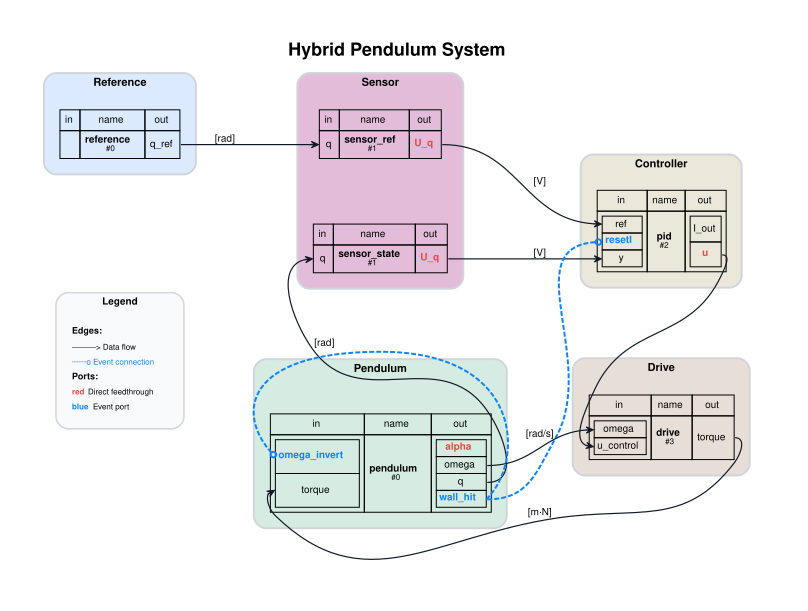

In [8]:
from syssimx.viz.sysgraph import SystemGraphVisualizer

visualizer = SystemGraphVisualizer(hybrid_system)
t_end = 10
hybrid_system.initialize(t0=0.0)
hybrid_system.algorithm.verbose = False
visualizer.visualize()

In [9]:
hybrid_system.algorithm.verbose = True
hybrid_system._event_targets_by_source

{('pendulum', 'wall_hit'): ['pid', 'pendulum']}

In [10]:
hybrid_system.run(t0=0.0, tf=t_end, dt=0.001)

[Hybrid] Time: 2.0250 s
[Hybrid] Events detected in interval [2.02400000, 2.02500000]
[Hybrid] Crossings: [('pendulum', 'wall_hit')]
[Hybrid] Indicator for pendulum.wall_hit = -5.64804602e-07
[Hybrid] Initial events to handle: [('pendulum', 'wall_hit')]
[Hybrid] Located at t=(2.02483203, 0)
[Hybrid] Events to handle at t=(2.02483203, 0): [('pendulum', 'wall_hit')]
[Hybrid] Already handled events: set()
[Hybrid] Handling events at (2.02483203, 0): [('pendulum', 'wall_hit')]
[Hybrid] Events grouped by component for handling: {'pid': ['wall_hit'], 'pendulum': ['wall_hit']}

[Hybrid] End of event window
[Hybrid] Time: 2.1640 s
[Hybrid] Events detected in interval [2.16300000, 2.16400000]
[Hybrid] Crossings: [('pendulum', 'wall_hit')]
[Hybrid] Indicator for pendulum.wall_hit = -4.97117257e-07
[Hybrid] Initial events to handle: [('pendulum', 'wall_hit')]
[Hybrid] Located at t=(2.16351562, 0)
[Hybrid] Events to handle at t=(2.16351562, 0): [('pendulum', 'wall_hit')]
[Hybrid] Already handled e

In [11]:
history = hybrid_system.get_history()

ref_history = history["reference"]
pid_history = history["pid"]
pendulum_history = history["pendulum"]
event_history = history["Events"]

t_ref, data = ref_history
q_ref = data["q_ref"]
t_pendulum, data = pendulum_history
q_pendulum = data["q"]
t_pid, data = pid_history
i_out = data["I_out"]

event_times = event_history[("pendulum", "wall_hit")]

In [12]:
event_times = [et.t for et in event_times]

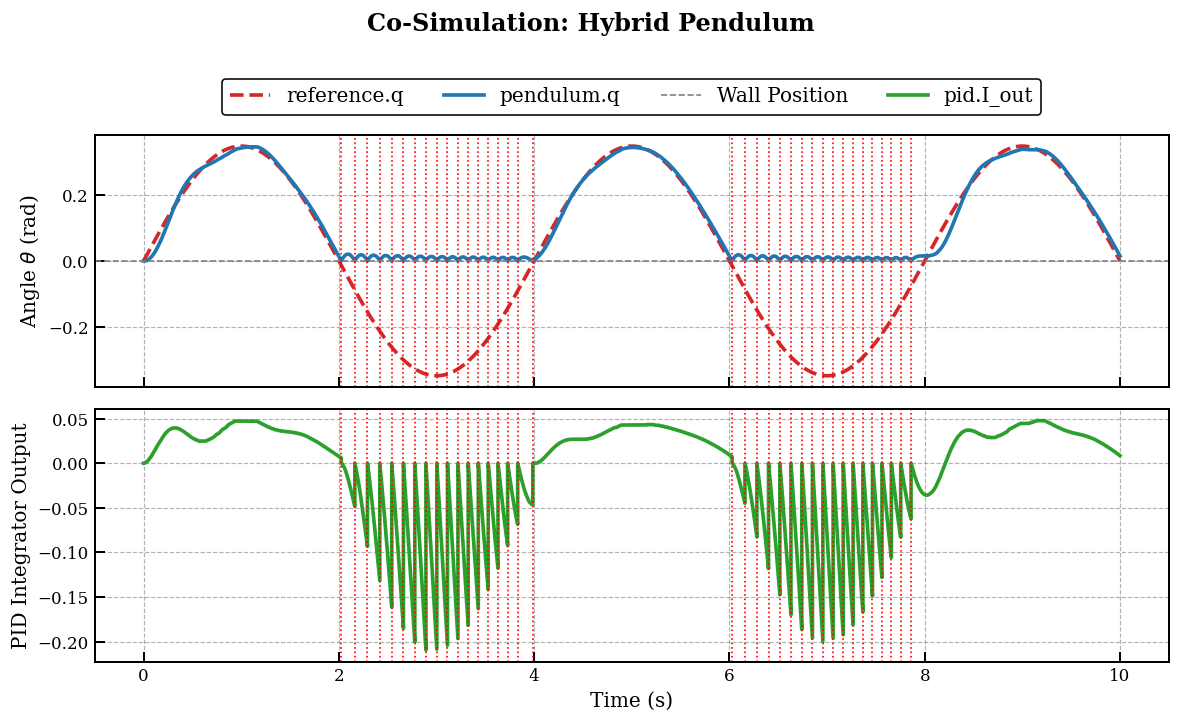

In [14]:
fig, axs = plt.subplots(ncols=1, nrows=2, sharex=True)
fig.set_size_inches(10, 6)

fig.suptitle(r"Co-Simulation: Hybrid Pendulum", fontweight="bold", y=1)

(s1,) = axs[0].plot(t_ref, q_ref, label="reference.q", color="tab:red", linestyle="--")
(s2,) = axs[0].plot(t_pendulum, q_pendulum, label="pendulum.q", color="tab:blue")
s3 = axs[0].axhline(0, label="Wall Position", color="gray", linestyle="--", linewidth=1)
axs[0].set_ylabel(r"Angle $\theta$ (rad)")
axs[0].grid()

(s4,) = axs[1].plot(t_pid, i_out, label="pid.I_out", color="tab:green")
axs[1].set_ylabel("PID Integrator Output")
axs[1].set_xlabel("Time (s)")
axs[1].grid()

handles = [s1, s2, s3, s4]
axs[0].legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 1.15), ncols=4)

for t_event in event_times:
    axs[0].axvline(t_event, color="red", linestyle=":", linewidth=1)
    axs[1].axvline(t_event, color="red", linestyle=":", linewidth=1)

plt.savefig("../figures/Hybrid/test_6_hybrid_pendulum.svg")
plt.tight_layout()
plt.show()

In [29]:
res_file_path = Path("results/hybrid_pendulum_cvode_1e-3.csv")
hybrid_system.history.save_csv(res_file_path)

Results saved to: results/hybrid_pendulum_cvode_1e-3.csv


------------------------------


## Comparision: Monolithic vs. Co-Simulation

**Pendulum Angle**

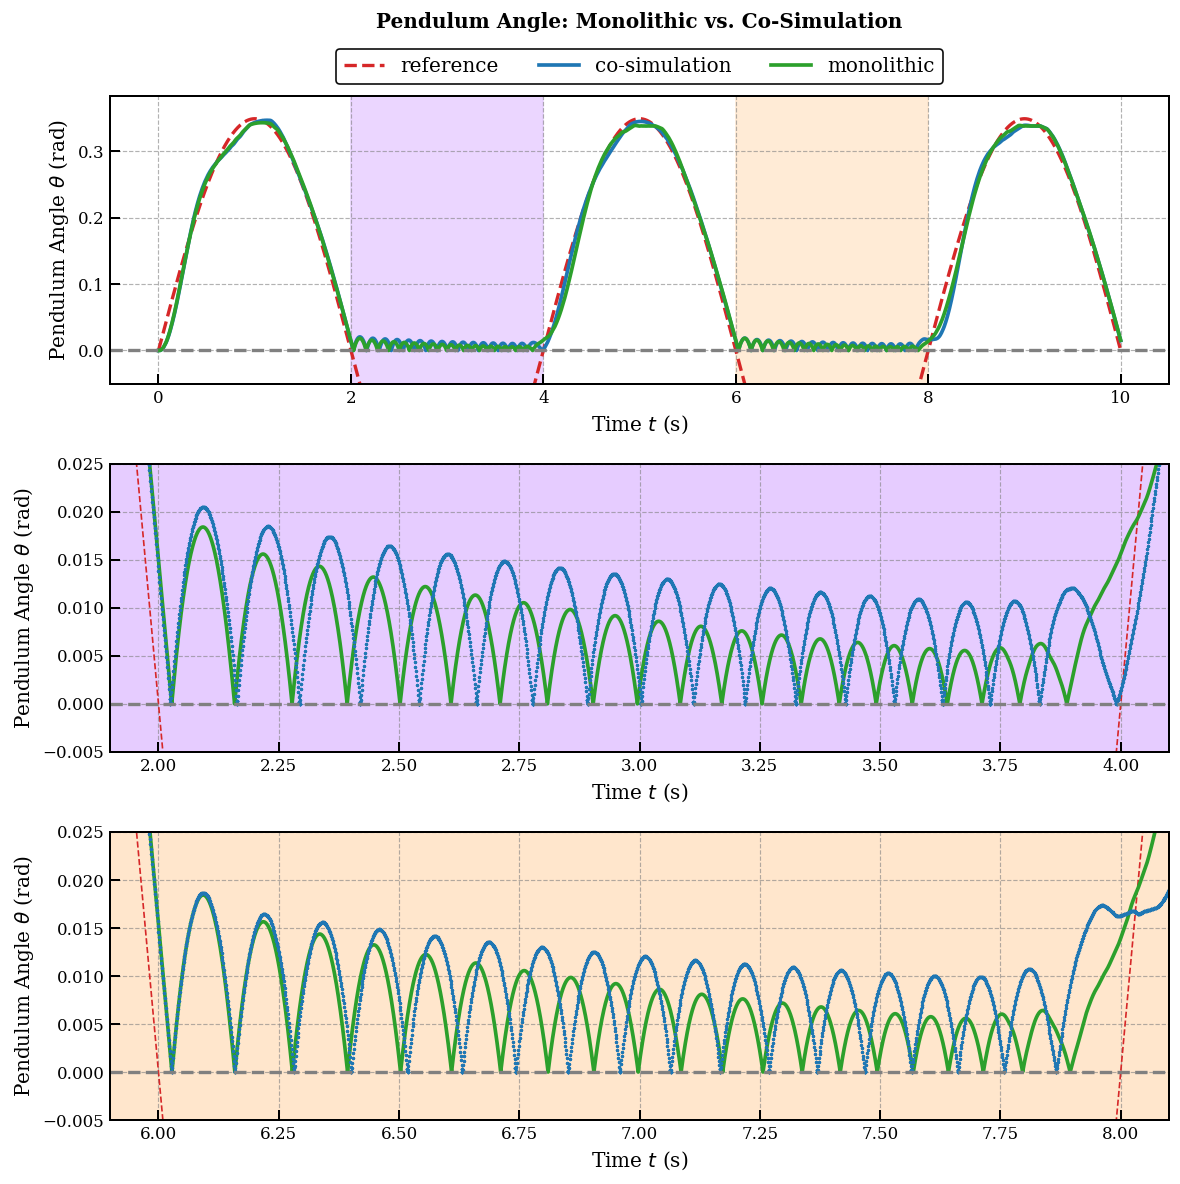

In [30]:
plt.figure(figsize=(10, 10))

zoom1_color = (0.9, 0.8, 1.0)  # Purple for first zoom region
zoom2_color = (1.0, 0.9, 0.8)  # Orange for second zoom region

plt.subplot(3, 1, 1)
plt.title(r"Pendulum Angle: Monolithic vs. Co-Simulation", fontweight="bold", y=1.2)
plt.plot(t_ref, q_ref, label="reference", color="tab:red", linestyle="--", linewidth=2)
plt.plot(t_pendulum, q_pendulum, label="co-simulation", color="tab:blue")
plt.plot(res["time"], res["pendulum.q"], label="monolithic", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=2)
plt.ylabel(r"Pendulum Angle $\theta$ (rad)")
plt.xlabel(r"Time $t$ (s)")
plt.ylim(-0.05)
plt.grid()
plt.legend(loc="center", bbox_to_anchor=(0.5, 1.1), ncol=3)

plt.axvspan(2, 4, color=zoom1_color, alpha=0.8)
plt.axvspan(6, 8, color=zoom2_color, alpha=0.8)

plt.subplot(3, 1, 2)
plt.plot(t_ref, q_ref, label="reference", color="tab:red", linestyle="--", linewidth=1)
plt.plot(res["time"], res["pendulum.q"], label="monolithic", color="tab:green")
plt.plot(
    t_pendulum,
    q_pendulum,
    label="co-simulation",
    color="tab:blue",
    marker="o",
    markersize=1,
    linestyle="None",
)
plt.axhline(0, color="gray", linestyle="--", linewidth=2)
plt.ylabel(r"Pendulum Angle $\theta$ (rad)")
plt.xlabel(r"Time $t$ (s)")
plt.xlim(1.9, 4.1)
plt.ylim(-0.005, 0.025)
plt.grid()
plt.gca().set_facecolor((0.9, 0.8, 1.0))

plt.subplot(3, 1, 3)
plt.plot(t_ref, q_ref, label="reference", color="tab:red", linestyle="--", linewidth=1)
plt.plot(res["time"], res["pendulum.q"], label="monolithic", color="tab:green")
plt.plot(
    t_pendulum,
    q_pendulum,
    label="co-simulation",
    color="tab:blue",
    marker="o",
    markersize=1,
    linestyle="None",
)
plt.axhline(0, color="gray", linestyle="--", linewidth=2)
plt.ylabel(r"Pendulum Angle $\theta$ (rad)")
plt.xlabel(r"Time $t$ (s)")
plt.xlim(5.9, 8.1)
plt.ylim(-0.005, 0.025)
plt.grid()
plt.gca().set_facecolor((1.0, 0.9, 0.8))

plt.tight_layout()
plt.savefig("../figures/Hybrid/test_6_hybrid_pendulum_comparison_1.svg")
plt.show()

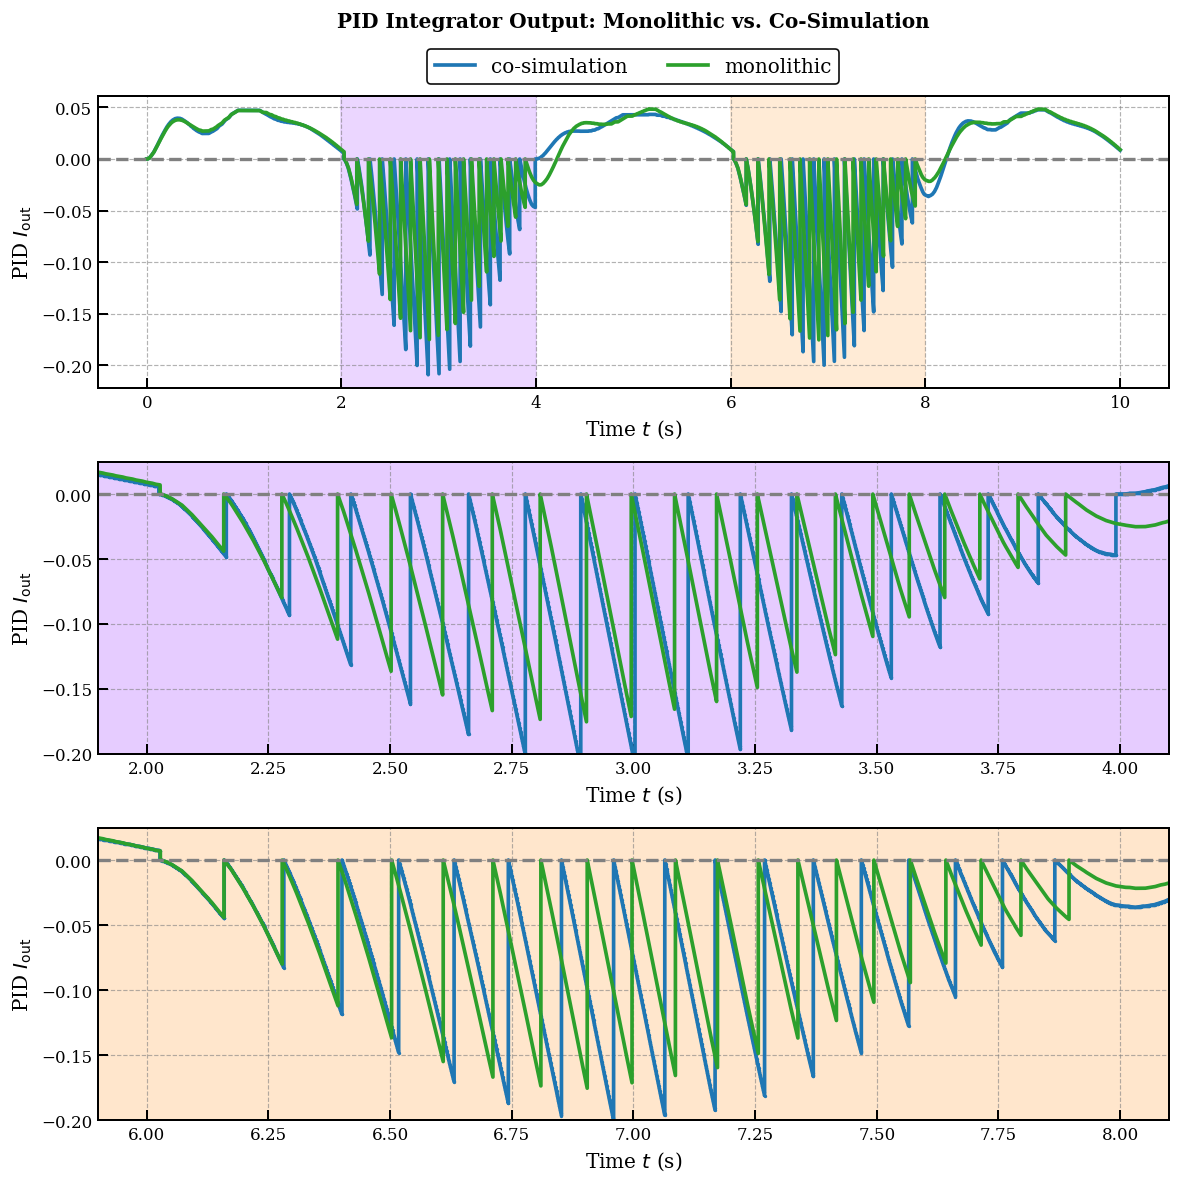

In [31]:
plt.figure(figsize=(10, 10))

zoom1_color = (0.9, 0.8, 1.0)  # Purple for first zoom region
zoom2_color = (1.0, 0.9, 0.8)  # Orange for second zoom region

plt.subplot(3, 1, 1)
plt.title(r"PID Integrator Output: Monolithic vs. Co-Simulation", fontweight="bold", y=1.2)
plt.plot(t_pid, i_out, label="co-simulation", color="tab:blue")
plt.plot(res["time"], res["pid.I_out"], label="monolithic", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=2)
plt.ylabel(r"PID $I_{\text{out}}$")
plt.xlabel(r"Time $t$ (s)")
plt.grid()
plt.legend(loc="center", bbox_to_anchor=(0.5, 1.1), ncol=3)

plt.axvspan(2, 4, color=zoom1_color, alpha=0.8)
plt.axvspan(6, 8, color=zoom2_color, alpha=0.8)

plt.subplot(3, 1, 2)
plt.plot(
    t_pid,
    i_out,
    label="co-simulation",
    color="tab:blue",
    marker="o",
    markersize=1,
)
plt.plot(res["time"], res["pid.I_out"], label="monolithic", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=2)
plt.ylabel(r"PID $I_{\text{out}}$")
plt.xlabel(r"Time $t$ (s)")
plt.xlim(1.9, 4.1)
plt.ylim(-0.2, 0.025)
plt.grid()
plt.gca().set_facecolor((0.9, 0.8, 1.0))

plt.subplot(3, 1, 3)
plt.plot(
    t_pid,
    i_out,
    label="co-simulation",
    color="tab:blue",
    marker="o",
    markersize=1,
)
plt.plot(res["time"], res["pid.I_out"], label="monolithic", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=2)
plt.ylabel(r"PID $I_{\text{out}}$")
plt.xlabel(r"Time $t$ (s)")
plt.xlim(5.9, 8.1)
plt.ylim(-0.2, 0.025)
plt.grid()
plt.gca().set_facecolor((1.0, 0.9, 0.8))

plt.tight_layout()
plt.savefig("../figures/Hybrid/test_6_hybrid_pendulum_comparison_2.svg")
plt.show()